In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
batch1 = pickle.load(open(r'/Users/mahizhan/Documents/Sem7/Github/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/batch1.pkl', 'rb'))
#remove batteries that do not reach 80% capacity
del batch1['b1c8']
del batch1['b1c10']
del batch1['b1c12']
del batch1['b1c13']
del batch1['b1c22']

In [4]:
numBat1 = len(batch1.keys())
numBat1

41

In [5]:
batch2 = pickle.load(open(r'/Users/mahizhan/Documents/Sem7/Github/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/batch2.pkl','rb'))

In [6]:
# There are four cells from batch1 that carried into batch2, we'll remove the data from batch2
# and put it with the correct cell from batch1
batch2_keys = ['b2c7', 'b2c8', 'b2c9', 'b2c15', 'b2c16']
batch1_keys = ['b1c0', 'b1c1', 'b1c2', 'b1c3', 'b1c4']
add_len = [662, 981, 1060, 208, 482];

In [7]:
for i, bk in enumerate(batch1_keys):
    batch1[bk]['cycle_life'] = batch1[bk]['cycle_life'] + add_len[i]
    for j in batch1[bk]['summary'].keys():
        if j == 'cycle':
            batch1[bk]['summary'][j] = np.hstack((batch1[bk]['summary'][j], batch2[batch2_keys[i]]['summary'][j] + len(batch1[bk]['summary'][j])))
        else:
            batch1[bk]['summary'][j] = np.hstack((batch1[bk]['summary'][j], batch2[batch2_keys[i]]['summary'][j]))
    last_cycle = len(batch1[bk]['cycles'].keys())
    for j, jk in enumerate(batch2[batch2_keys[i]]['cycles'].keys()):
        batch1[bk]['cycles'][str(last_cycle + j)] = batch2[batch2_keys[i]]['cycles'][jk]

In [8]:
del batch2['b2c7']
del batch2['b2c8']
del batch2['b2c9']
del batch2['b2c15']
del batch2['b2c16']

In [9]:
numBat2 = len(batch2.keys())
numBat2

43

In [10]:
batch3 = pickle.load(open(r'/Users/mahizhan/Documents/Sem7/Github/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/batch3.pkl','rb'))
# remove noisy channels from batch3
del batch3['b3c37']
del batch3['b3c2']
del batch3['b3c23']
del batch3['b3c32']
del batch3['b3c42']
del batch3['b3c43']

In [11]:
numBat3 = len(batch3.keys())
numBat3

40

In [12]:
numBat = numBat1 + numBat2 + numBat3
numBat

124

In [13]:
bat_dict = {**batch1, **batch2, **batch3}

Text(0, 0.5, 'Discharge Capacity (Ah)')

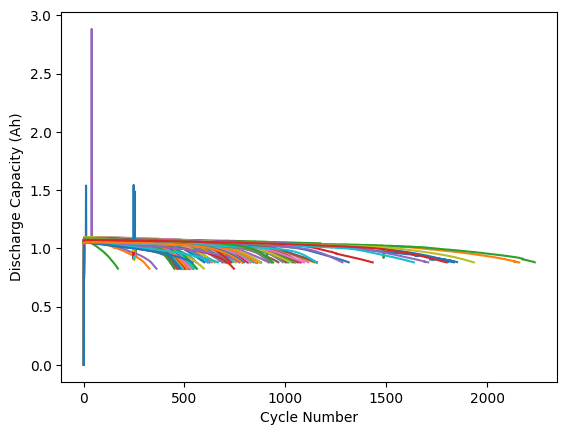

In [14]:
for i in bat_dict.keys():
    plt.plot(bat_dict[i]['summary']['cycle'], bat_dict[i]['summary']['QD'])
plt.xlabel('Cycle Number')
plt.ylabel('Discharge Capacity (Ah)')

In [62]:
test_ind = np.hstack((np.arange(0,(numBat1+numBat2),2),83))
train_ind = np.arange(1,(numBat1+numBat2-1),2)
secondary_test_ind = np.arange(numBat-numBat3,numBat);

In [61]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

def extract_180_features(bat_dict, num_points=60):
    X_list, y_list = [], []
    
    for bat_id, bat_data in bat_dict.items():
        cycles = bat_data['cycles']
        summary = bat_data['summary']
        
        # We need the capacity for the NEXT cycle as our target SOH
        capacities = summary['QD'] 
        
        for i in range(1, len(cycles) - 1):
            cycle_str = str(i)
            if cycle_str not in cycles:
                continue
                
            c_data = cycles[cycle_str]
            
            # Extract raw arrays
            V_raw = c_data['V']
            I_raw = c_data['I']
            T_raw = c_data['T']
            
            # Create a uniform linear grid based on array length
            grid_raw = np.linspace(0, 1, len(V_raw))
            grid_fixed = np.linspace(0, 1, num_points)
            
            # Interpolate to exactly 60 points each
            V_fixed = np.interp(grid_fixed, grid_raw, V_raw)
            I_fixed = np.interp(grid_fixed, grid_raw, I_raw)
            T_fixed = np.interp(grid_fixed, grid_raw, T_raw)
            
            # Strictly isolate the 180 features, removing all extra data
            features_180 = np.concatenate([V_fixed, I_fixed, T_fixed])
            
            X_list.append(features_180)
            y_list.append(capacities[i + 1]) # Target: Next cycle capacity
            
    # Convert to PyTorch Tensors (Shape: [Samples, Channels, Sequence Length])
    X_tensor = torch.FloatTensor(np.array(X_list)).unsqueeze(1) 
    y_tensor = torch.FloatTensor(np.array(y_list)).unsqueeze(1)
    
    return X_tensor, y_tensor

# Generate the dataset
X, y = extract_180_features(bat_dict)
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

In [63]:
class HealthAgent1DCNN(nn.Module):
    def __init__(self):
        super(HealthAgent1DCNN, self).__init__()
        
        # Input shape: (Batch, 1 Channel, 180 Features)
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # After convolutions, the 180 features are compressed
        # Dimension calculation: 180 -> conv1(90) -> pool(45) -> conv2(45) -> pool(22)
        # 32 channels * 22 sequence length = 704
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 22, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1) # Output: Predicted SOH (Capacity)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # Flatten
        out = self.fc_layers(x)
        return out

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
health_agent = HealthAgent1DCNN().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(health_agent.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    health_agent.train()
    running_loss = 0.0
    
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        predictions = health_agent(inputs)
        loss = criterion(predictions, targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(dataloader):.6f}")


model_path = "/Users/mahizhan/Documents/Sem7/Github/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/Model/health_agent_1dcnn.pth"

torch.save(health_agent.state_dict(), model_path)

print(f"\nModel saved successfully to:\n{model_path}")

Epoch 1/50 - Loss: 0.023806
Epoch 2/50 - Loss: 0.009284
Epoch 3/50 - Loss: 0.006965
Epoch 4/50 - Loss: 0.004653
Epoch 5/50 - Loss: 0.002870
Epoch 6/50 - Loss: 0.001543
Epoch 7/50 - Loss: 0.000765
Epoch 8/50 - Loss: 0.000381
Epoch 9/50 - Loss: 0.000269
Epoch 10/50 - Loss: 0.000225
Epoch 11/50 - Loss: 0.000216
Epoch 12/50 - Loss: 0.000197
Epoch 13/50 - Loss: 0.000207
Epoch 14/50 - Loss: 0.000190
Epoch 15/50 - Loss: 0.000179
Epoch 16/50 - Loss: 0.000174
Epoch 17/50 - Loss: 0.000163
Epoch 18/50 - Loss: 0.000159
Epoch 19/50 - Loss: 0.000159
Epoch 20/50 - Loss: 0.000160
Epoch 21/50 - Loss: 0.000155
Epoch 22/50 - Loss: 0.000142
Epoch 23/50 - Loss: 0.000150
Epoch 24/50 - Loss: 0.000145
Epoch 25/50 - Loss: 0.000131
Epoch 26/50 - Loss: 0.000151
Epoch 27/50 - Loss: 0.000141
Epoch 28/50 - Loss: 0.000131
Epoch 29/50 - Loss: 0.000128
Epoch 30/50 - Loss: 0.000117
Epoch 31/50 - Loss: 0.000118
Epoch 32/50 - Loss: 0.000114
Epoch 33/50 - Loss: 0.000137
Epoch 34/50 - Loss: 0.000107
Epoch 35/50 - Loss: 0.0

In [66]:
class BatteryThermalSim:
    def __init__(self, dt=1.0, ambient_temp=34.0):     
        self.dt = dt
        self.ambient_temp = ambient_temp
        
        self.C_thermal = 300.0  
        self.R_internal = 0.12  
        
        # DOWN from 60.0: Lower max cooling power so it can't plunge the temp to 18°C
        self.max_cooling_power = 25.0 
        
        self.h_conv = 3.0                                
        self.reset()

    def reset(self, start_temp=None):
        self.T = start_temp if start_temp is not None else self.ambient_temp
        self.t = 0
        return np.array([self.T], dtype=np.float32)

    def step(self, current_A, cooling_action):
        cooling_power = (cooling_action + 1) / 2 * self.max_cooling_power
        cooling_power = np.clip(cooling_power, 0, self.max_cooling_power)

        Q_gen = (current_A ** 2) * self.R_internal
        Q_ambient_loss = self.h_conv * (self.T - self.ambient_temp)
        dT = (Q_gen - cooling_power - Q_ambient_loss) / self.C_thermal * self.dt

        self.T += dT
        self.t += self.dt

        return np.array([self.T], dtype=np.float32), cooling_power

In [67]:
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import NormalizeObservation

env = ThermalEnv()
env = NormalizeObservation(env)  # wraps obs to running mean/std normalized

class ThermalEnv(gym.Env):
    # Anchored to your empirical dataset boundaries
    def __init__(self, target_temp=36.0, safe_max_temp=42.5, episode_len=500):
        super().__init__()
        self.sim = BatteryThermalSim()
        self.target_temp = target_temp
        self.safe_max_temp = safe_max_temp
        
        # Add this line back in!
        self.episode_len = episode_len 

        # action: cooling power, continuous, normalized [-1, 1]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        # state: [current_temp, current_A_now]
        self.observation_space = spaces.Box(low=-50, high=150, shape=(2,), dtype=np.float32)

        self.current_profile = None
        self.step_count = 0

    def _sample_current_profile(self):
        # Mix of a baseline current with occasional fast-charge spikes —
        # this creates periods where active cooling is actually necessary
        base = np.random.uniform(2.0, 4.0)
        profile = np.full(self.episode_len, base)

        n_spikes = np.random.randint(2, 5)
        for _ in range(n_spikes):
            spike_start = np.random.randint(0, self.episode_len - 50)
            spike_len = np.random.randint(20, 50)
            spike_current = np.random.uniform(8.0, 14.0)
            profile[spike_start:spike_start + spike_len] = spike_current

        noise = np.random.normal(0, 0.2, self.episode_len)
        return np.clip(profile + noise, 0, 15.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        T0 = self.sim.reset(start_temp=np.random.uniform(32.0, 35.0))
        self.current_profile = self._sample_current_profile()
        self.step_count = 0
        obs = np.array([T0[0], self.current_profile[0]], dtype=np.float32)
        return obs, {}

    def step(self, action):
        current_A = self.current_profile[self.step_count]
        T_new, cooling_power = self.sim.step(current_A, action[0])

        temp_penalty = -abs(T_new[0] - self.target_temp) / 5.0
        energy_penalty = -0.005 * cooling_power
        safety_penalty = -10.0 if T_new[0] > self.safe_max_temp else 0.0
        reward = float(temp_penalty + energy_penalty + safety_penalty)
        self.step_count += 1
        terminated = bool(T_new[0] > self.safe_max_temp + 10)   # cast to plain bool
        truncated = bool(self.step_count >= self.episode_len)   # cast to plain bool

        next_current = self.current_profile[min(self.step_count, self.episode_len - 1)]
        obs = np.array([T_new[0], next_current], dtype=np.float32)

        return obs, reward, terminated, truncated, {"temp": float(T_new[0]), "cooling_power": float(cooling_power)}

In [68]:
import gymnasium as gym
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.env_checker import check_env

env = ThermalEnv()
check_env(env)  # sanity check — will raise errors if the env API is malformed

n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

model = DDPG(
    "MlpPolicy",
    env,
    action_noise=action_noise,
    learning_rate=1e-4,        # DOWN from 1e-3
    buffer_size=50000,
    learning_starts=5000,      # UP from 1000 — more random exploration before learning starts
    batch_size=256,            # UP from 128
    gamma=0.98,
    tau=0.005,                 # explicit soft-update rate, SB3 default but worth pinning
    verbose=1,
    tensorboard_log="./thermal_agent_tb/"
)

model.learn(total_timesteps=100_000)
model.save("thermal_agent_ddpg")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./thermal_agent_tb/DDPG_7
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -476     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 11183    |
|    time_elapsed    | 0        |
|    total_timesteps | 2000     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -454     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 12108    |
|    time_elapsed    | 0        |
|    total_timesteps | 4000     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -411     |
| time/              |          |
|    episodes      

In [58]:
import numpy as np

def eval_fixed_action(action_val, env, n_episodes=10):
    all_temps = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            action = np.array([action_val], dtype=np.float32)
            obs, reward, terminated, truncated, info = env.step(action)
            all_temps.append(info["temp"])
            done = terminated or truncated
    return np.array(all_temps)

# Instantiate the updated environment
env_diagnostic = ThermalEnv()

# Run diagnostics for the two extremes
no_cooling = eval_fixed_action(-1.0, env_diagnostic)
full_cooling = eval_fixed_action(1.0, env_diagnostic)

print("No cooling   — mean temp:", round(no_cooling.mean(), 2), "| max:", round(no_cooling.max(), 2))
print("Full cooling — mean temp:", round(full_cooling.mean(), 2), "| max:", round(full_cooling.max(), 2))

No cooling   — mean temp: 35.04 | max: 37.28
Full cooling — mean temp: 18.98 | max: 34.78
